In [110]:
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sys.path.append(r"D:/Football Project/src")

import feature_lists as fl

In [111]:
df=pd.read_csv('../../../data/processed/major_leagues/EWMA_Major_Leagues.csv')

In [112]:
df=df[df['position']=='Forwards']

In [113]:
df=df.drop(columns=fl.goalkeeper_features_z)

In [114]:
df=df.drop(columns=fl.discipline_features_z)

In [115]:
df=df.drop(columns=[
    "fouls_zscore",
    "fouls_per90_zscore",
    "tackles_zscore",
    "tackleswon_zscore",
    "tackleswonpercentage_zscore",
    "possessionwonattthird_zscore",
    "clearances_zscore",
    "blockedshots_zscore",
    "dribbledpast_zscore",
    "errorleadtoshot_zscore",
    "errorleadtogoal_zscore",
    "tackles_per90_zscore",
    "tackleswon_per90_zscore",
    "possessionwonattthird_per90_zscore",
    "clearances_per90_zscore",
    "blockedshots_per90_zscore",
    "dribbledpast_per90_zscore",
    "errorleadtoshot_per90_zscore",
    "errorleadtogoal_per90_zscore",
    ])

In [116]:
df=df.drop(columns=[
    'rating_zscore',
    'accuratepassespercentage_zscore', 
    'opp_half_pass_pct_zscore',
])

In [117]:
existing_cols_to_drop = [col for col in fl.volume_zscore_cols if col in df.columns]
df = df.drop(columns=existing_cols_to_drop)

In [118]:
df.shape

(867, 86)

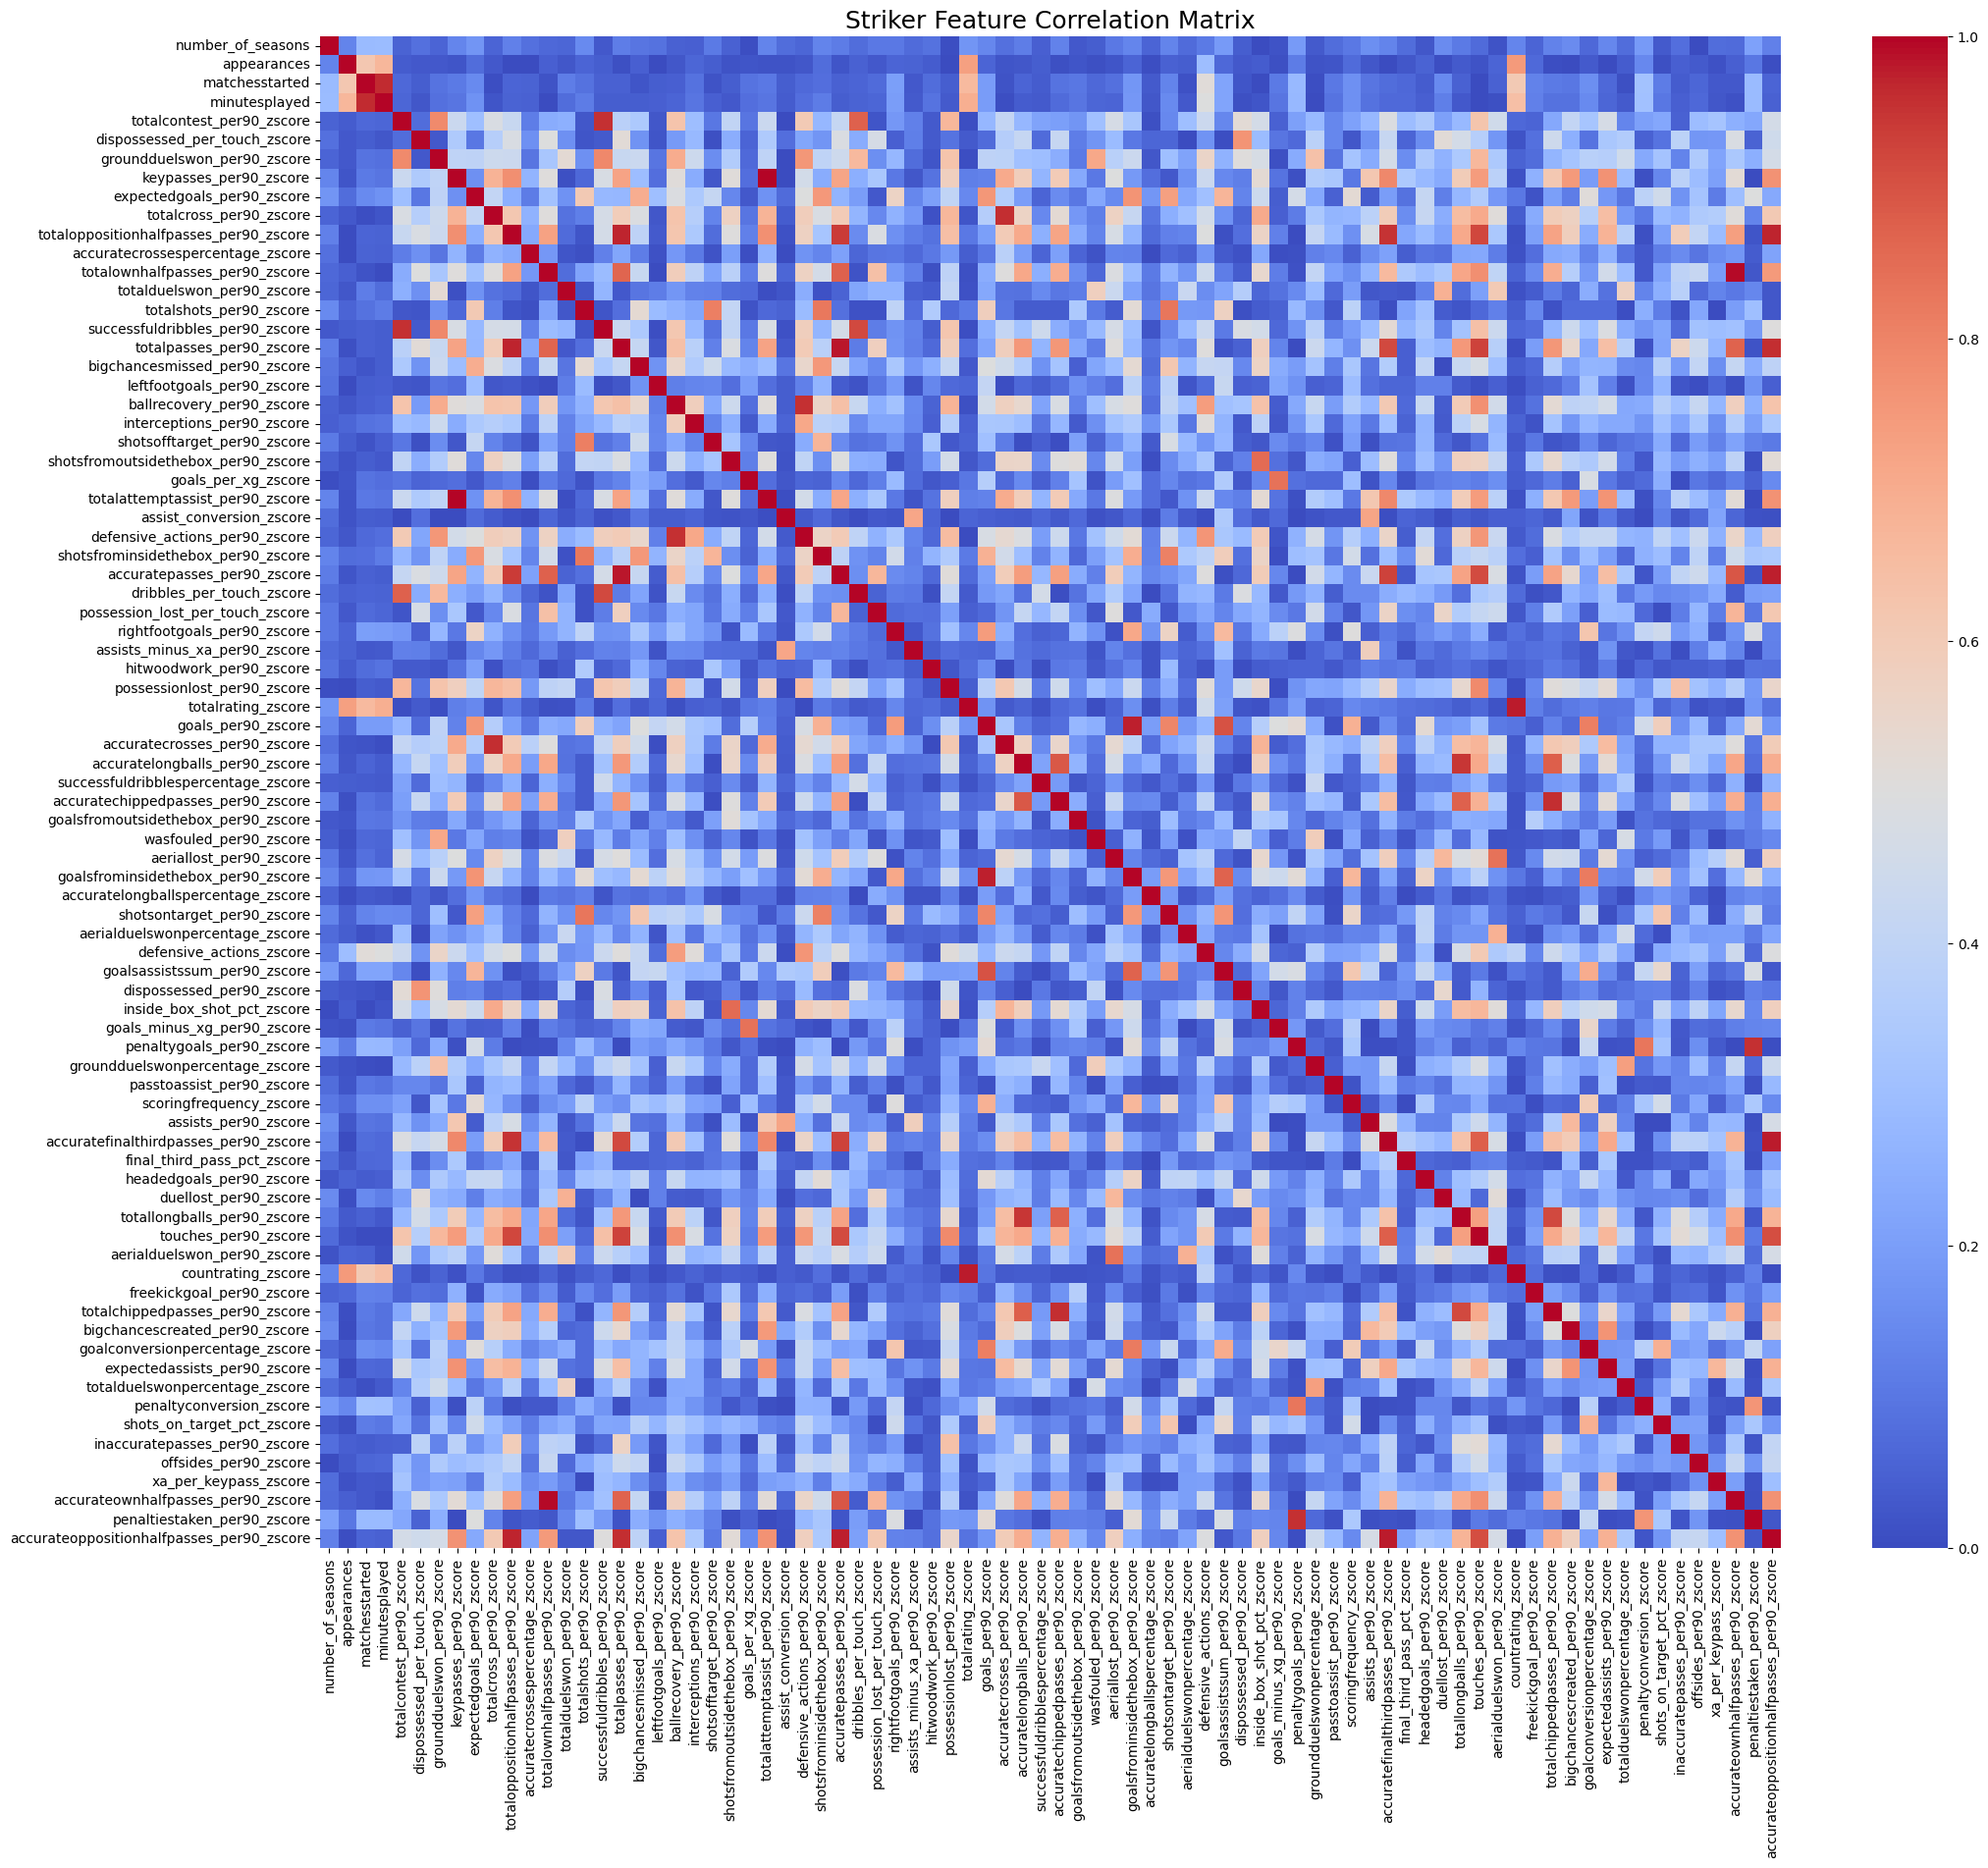

In [119]:
corr_matrix = df.drop(columns=fl.metadata_features).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [120]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,keypasses_per90_zscore,totalattemptassist_per90_zscore,0.999447
1,totalownhalfpasses_per90_zscore,accurateownhalfpasses_per90_zscore,0.992802
2,totalpasses_per90_zscore,accuratepasses_per90_zscore,0.982035
3,totalrating_zscore,countrating_zscore,0.978270
4,accuratefinalthirdpasses_per90_zscore,accurateoppositionhalfpasses_per90_zscore,0.978004
5,accuratepasses_per90_zscore,accurateoppositionhalfpasses_per90_zscore,0.973776
6,goals_per90_zscore,goalsfrominsidethebox_per90_zscore,0.973295
7,totaloppositionhalfpasses_per90_zscore,accurateoppositionhalfpasses_per90_zscore,0.972122
8,totaloppositionhalfpasses_per90_zscore,totalpasses_per90_zscore,0.969573
9,matchesstarted,minutesplayed,0.964824


In [121]:
df=df.drop(columns=[
    'totalattemptassist_per90_zscore','totalownhalfpasses_per90_zscore',
    'totalpasses_per90_zscore','totalrating_zscore','countrating_zscore',
    'accurateoppositionhalfpasses_per90_zscore','goalsfrominsidethebox_per90_zscore',
    'totaloppositionhalfpasses_per90_zscore','totalcross_per90_zscore',
    'totalchippedpasses_per90_zscore','totallongballs_per90_zscore','goalsassistssum_per90_zscore',
    'penaltiestaken_per90_zscore','aeriallost_per90_zscore','accuratechippedpasses_per90_zscore',
    'totalcontest_per90_zscore','dribbles_per_touch_zscore','defensive_actions_per90_zscore',
    'accuratepasses_per90_zscore','touches_per90_zscore','inside_box_shot_pct_zscore',
    'totalshots_per90_zscore',
])

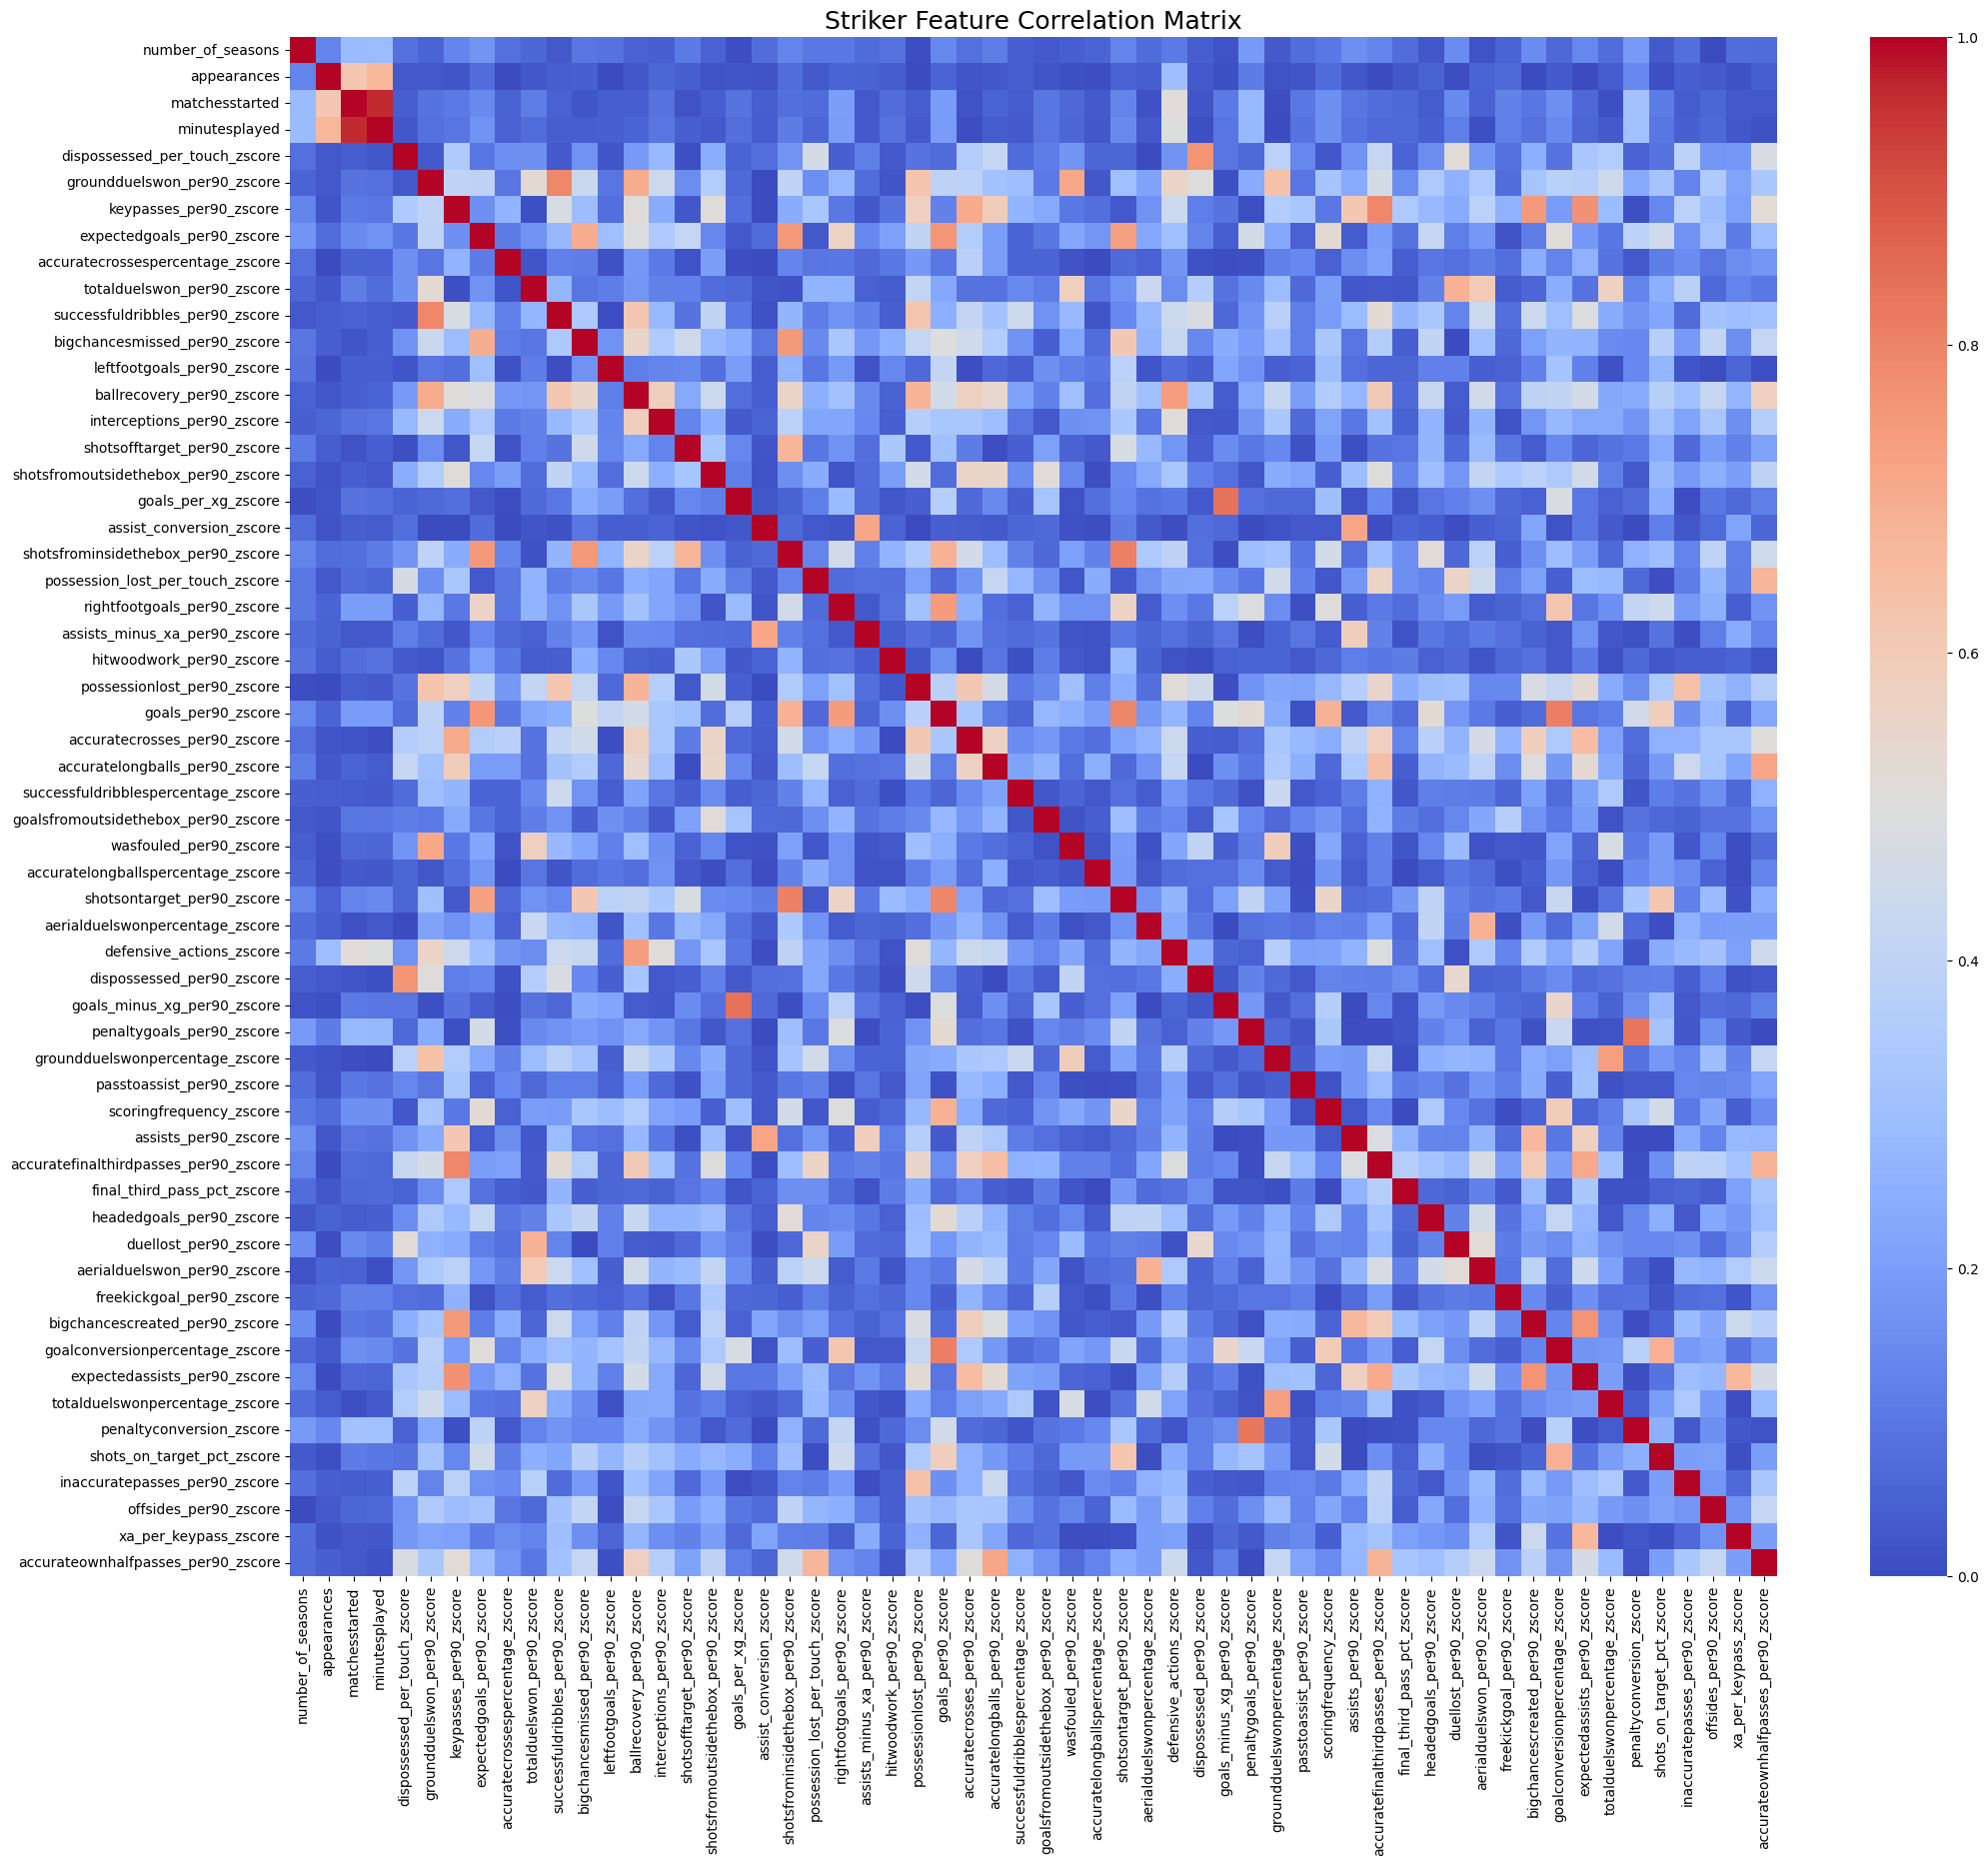

In [122]:
corr_matrix = df.drop(columns=fl.metadata_features).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [123]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,matchesstarted,minutesplayed,0.964824
1,goals_per_xg_zscore,goals_minus_xg_per90_zscore,0.836974
2,penaltygoals_per90_zscore,penaltyconversion_zscore,0.830039
3,goals_per90_zscore,goalconversionpercentage_zscore,0.808745
4,shotsfrominsidethebox_per90_zscore,shotsontarget_per90_zscore,0.804746


In [124]:
df.shape

(867, 64)

In [125]:
df.columns.to_list()

['player id',
 'player',
 'team id',
 'team',
 'league',
 'position',
 'number_of_seasons',
 'appearances',
 'matchesstarted',
 'minutesplayed',
 'dispossessed_per_touch_zscore',
 'groundduelswon_per90_zscore',
 'keypasses_per90_zscore',
 'expectedgoals_per90_zscore',
 'accuratecrossespercentage_zscore',
 'totalduelswon_per90_zscore',
 'successfuldribbles_per90_zscore',
 'bigchancesmissed_per90_zscore',
 'leftfootgoals_per90_zscore',
 'ballrecovery_per90_zscore',
 'interceptions_per90_zscore',
 'shotsofftarget_per90_zscore',
 'shotsfromoutsidethebox_per90_zscore',
 'goals_per_xg_zscore',
 'assist_conversion_zscore',
 'shotsfrominsidethebox_per90_zscore',
 'possession_lost_per_touch_zscore',
 'rightfootgoals_per90_zscore',
 'assists_minus_xa_per90_zscore',
 'hitwoodwork_per90_zscore',
 'possessionlost_per90_zscore',
 'goals_per90_zscore',
 'accuratecrosses_per90_zscore',
 'accuratelongballs_per90_zscore',
 'successfuldribblespercentage_zscore',
 'goalsfromoutsidethebox_per90_zscore',
 '

In [126]:
df.to_csv('../../../data/processed/major_leagues/Forwards/EWMA_Major_Forwards.csv',index=False)